In [1]:
# Real scalar boson star or oscillaton example
# see further details in https://github.com/GRChombo/engrenage/wiki/Running-the-oscillaton-example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [2]:
# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# Modified Gravity
sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/SGB_Oscillons/source')
#sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/SGB_BR/source')


from core.grid import Grid
from core.rhsevolution_MG import *
from core.spacing import *
from core.display import * 
from core.statevector import *
from matter.scalarmatter_MG import *
from initialdata.ModifiedGravityInitialConditions import *
from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *

# Setting Up

In [3]:
####################################################
# CHOOSE SIMULATION PARAMETERS
####################################################

#scalar_mu = 1.0
scalar_mu = 1
my_matter = ScalarMatter(scalar_mu)
my_state_vector = StateVector(my_matter)

#Modified Gravity parameters
lambda_GB = 0.001
a = 0.2
b= 0.4
chi0 = 0.15

# Grouping parameters
ppp = (lambda_GB, a, b, chi0)

####################################################
# CHOOSE RESOLUTION PARAMETERS
####################################################

# 'LOW' Resolution
r_max = 96.0 # outer edge of the grid (including ghosts)
min_dr = 1 / 16
max_dr = 2

# CubicSpacing
params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
spacing = CubicSpacing(**params)

# Grid
grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size
background = FlatSphericalBackground(r)

# Check grid params
print(params)

"""
# 'High Resolution'
# Input parameters for HR grid
min_dr_HR = 1 / 32 # roughly 64 points across the BH
max_dr_HR = 1

# CubicSpacing
params_HR = CubicSpacing.get_parameters(r_max, min_dr_HR, max_dr_HR)
spacing_HR = CubicSpacing(**params_HR)

grid_HR = Grid(spacing_HR, my_state_vector)
r_HR = grid_HR.r
num_points_HR = r_HR.size
background_HR = FlatSphericalBackground(r_HR)

# Check grid params
print(params_HR)
print("PARAMETERS: ", "lambda_GB: ", lambda_GB, "a(x): ",a, "b(x): ",b,  "chi0: ", chi0)
"""

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 140}


'\n# \'High Resolution\'\n# Input parameters for HR grid\nmin_dr_HR = 1 / 32 # roughly 64 points across the BH\nmax_dr_HR = 1\n\n# CubicSpacing\nparams_HR = CubicSpacing.get_parameters(r_max, min_dr_HR, max_dr_HR)\nspacing_HR = CubicSpacing(**params_HR)\n\ngrid_HR = Grid(spacing_HR, my_state_vector)\nr_HR = grid_HR.r\nnum_points_HR = r_HR.size\nbackground_HR = FlatSphericalBackground(r_HR)\n\n# Check grid params\nprint(params_HR)\nprint("PARAMETERS: ", "lambda_GB: ", lambda_GB, "a(x): ",a, "b(x): ",b,  "chi0: ", chi0)\n'

# Initial Data

In [4]:
initial_state = get_initial_state(grid, background, ppp, my_matter)

#unpackage the vector for readability
(initial_phi, initial_hrr, initial_htt, initial_hpp, 
 initial_K, initial_arr, initial_att, initial_app, 
 initial_lambdar, initial_shiftr, initial_br, initial_lapse,
 initial_u, initial_v) = np.array_split(initial_state, grid.NUM_VARS)

plt.xlim(0, 40)
plt.ylabel("Ham Constraint")

TypeError: get_initial_state() missing 1 required positional argument: 'bump_amplitude'

In [5]:
initial_state_HR = get_initial_state(grid_HR, background_HR, ppp, my_matter)
plt.xlim(0, 40)
plt.ylabel("Ham Constraint")

NameError: name 'grid_HR' is not defined

NameError: name 'initial_arr' is not defined

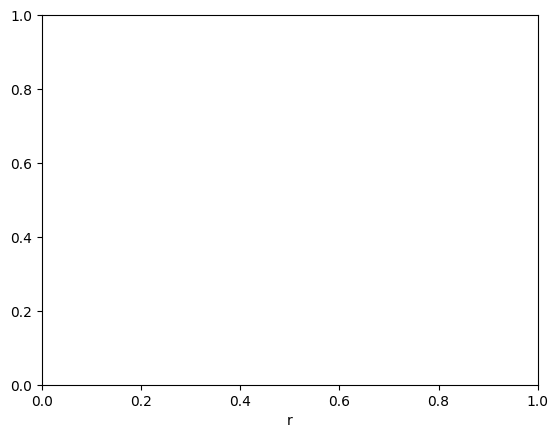

In [6]:
#plot initial conditions
plt.xlabel('r')
plt.plot(r, initial_arr, '.', label='arr') 
plt.plot(r, initial_hrr, '.', label='hrr')
plt.plot(r, initial_u, '.', label='u') 
plt.plot(r, initial_phi, '--', label='phi') 



#plt.plot(r, initial_u, '.', label='u') 
plt.legend(loc='best')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
#plt.xlim(-0.25,5.0)
plt.ylim(-1,1)

# Initial data resolution testing

In [7]:
# check the Hamiltonian and momentum constraints are initially satisfied
Ham, Mom = get_constraints_diagnostic(initial_state, np.array([0]), grid, background, my_matter,ppp)

# plot the profile for Ham
plt.plot(r, Ham[0], label="Ham")
#plt.plot(r, Mom[0], label="Mom")

plt.xlabel('r')
plt.ylabel('Constraints value')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.legend()
plt.xlim(0,20)
#plt.ylim(-0.1,0.1)



# Get initial state

# check the Hamiltonian and momentum constraints are initially satisfied
Ham_HR, Mom_HR = get_constraints_diagnostic(initial_state_HR, np.array([0]), grid_HR, background_HR, my_matter,ppp)


NameError: name 'initial_state' is not defined

In [8]:
# plot the profiles for Ham
plt.plot(r, Ham[0],'-',label="LR Ham")
plt.plot(r_HR, Ham_HR[0],'--',label="HR Ham")
plt.plot(r_HR, Ham_HR[0] * 2.0**2.0,':',label="LR Ham predicted by 2nd order convergence")

plt.xlabel('r')
plt.ylabel('Ham value')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(0,16)
#plt.ylim(-0.0015,10**(-4)) 
plt.legend();

NameError: name 'Ham' is not defined

# Start running the simulation

In [ ]:
# Time ?
T = 10 # Maximum evolution time
num_points_t = 101 # time resolution (only for outputs, not for integration)

# Work out dt and time spacing of outputs
dt = T/num_points_t
t = np.linspace(0, T-dt, num_points_t)

# Solve for the solution using RK45 integration of the ODE
# to make like (older) python odeint method use method='LSODA' instead
# use tqdm package to track progress
with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution = solve_ivp(get_rhs, [0,T], initial_state, 
                               #args=(grid, background, my_matter, progress_bar, [0, T/1000], 0.2, 0.4, 0.05),
                               args=(grid, background, my_matter, progress_bar, [0, T/1000], a, b, lambda_GB),
                        #atol=1e-5, rtol=1e-5,
                        max_step = 0.4 * min_dr, #for stability and for KO coeff of 1
                        method='RK45', dense_output=True)


# Interpolate the solution at the time points defined in myparams.py
solution = dense_solution.sol(t).T

In [12]:
inta = 0
for i in range(len(my_state_vector.VARIABLE_NAMES)):
    print('Index: ', inta, 'Variable Name: ',  my_state_vector.VARIABLE_NAMES[i])
    inta = inta +1

Index:  0 Variable Name:  phi
Index:  1 Variable Name:  hrr
Index:  2 Variable Name:  htt
Index:  3 Variable Name:  hpp
Index:  4 Variable Name:  K
Index:  5 Variable Name:  arr
Index:  6 Variable Name:  att
Index:  7 Variable Name:  app
Index:  8 Variable Name:  lambdar
Index:  9 Variable Name:  shiftr
Index:  10 Variable Name:  br
Index:  11 Variable Name:  lapse
Index:  12 Variable Name:  u
Index:  13 Variable Name:  v


# Simulation Loop

In [ ]:
lambda_vals = [0.08]
perturbations = [1e-6,1e-5, 1e-4]

plt.figure()
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(vmin=0, vmax=len(lambda_vals)-1)

ALL_SOLS = []
ALL_BHM = []

for i, perturbation in enumerate(perturbations):
    for j, constant in enumerate(lambda_vals):
        initial_state = get_initial_state(grid, background, (lambda_vals[j], a, b, chi0), my_matter,perturbation )
    
        # time settings
        T = 100
        num_points_t = 101
        dt = T/num_points_t
        t = np.linspace(0, T-dt, num_points_t)
    
        # solve
        with tqdm(total=1000, unit="‰") as progress_bar:
            dense_solution = solve_ivp(
                get_rhs, [0,T], initial_state,
                args=(grid, background, my_matter, progress_bar, [0, T/1000], a, b, 0.05),
                max_step=0.4 * min_dr,
                method='RK45',
                dense_output=True
            )
    
        solution = dense_solution.sol(t).T
    
        # diagnostics
        omega, ah_radius, bh_mass = get_horizon_diagnostics(solution, t, grid, background, my_matter)

        ALL_SOLS.append(solution)
        ALL_BHM.append(bh_mass)
        
        """
        # unique color
        color = cmap(norm(i))
    
        # plot black hole mass versus time
        plt.plot(t, bh_mass, '-', color="orange", label=perturbation)
    
        # you can also add another curve per run if you want:
        idx = NUM_GHOSTS + 2
        var1_of_t = solution[:, 12 * num_points + idx]
        plt.plot(t, var1_of_t, '--', color="blue", label=perturbation)
        


plt.legend()
plt.xlabel("t")
plt.ylabel("value")
plt.grid()
plt.xlim(-0.1, 50)
plt.show()
"""


error is:  0.0009700945817000697  after iter:  5


  0%|          | 0/1000 [00:00<?, ?‰/s]

error is:  0.0008714784720057969  after iter:  12


  0%|          | 0/1000 [00:00<?, ?‰/s]

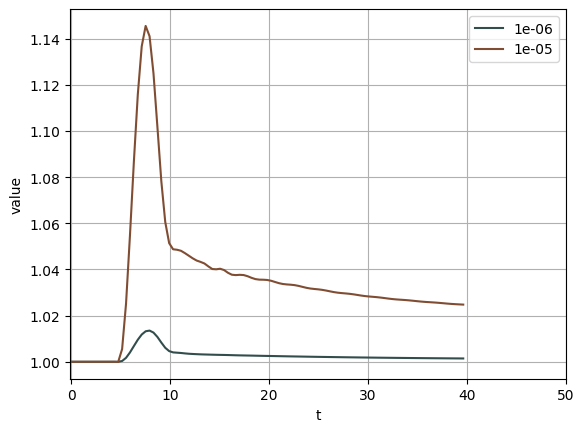

In [34]:
object = 11

for i in range(len(ALL_SOLS)):
    #color = cmap(norm(i)) 
    #plt.plot(t, ALL_BHM[i], '-', color="orange", label=lambda_vals[j])
    
    r = np.round(np.random.rand(),1)
    g = np.round(np.random.rand(),1)
    b = np.round(np.random.rand(),1)
    
    dx = NUM_GHOSTS + 2
    var1_of_t = ALL_SOLS[i][:, object * num_points + idx]
    plt.plot(t, var1_of_t, '-', color=[r, g,b], label=perturbations[i])

plt.legend()
plt.xlabel("t")
plt.ylabel(my_state_vector.VARIABLE_NAMES[object])
plt.grid()
plt.xlim(-0.1, 50)
plt.show()

# Lapse and collapse into BH mass 

0.0


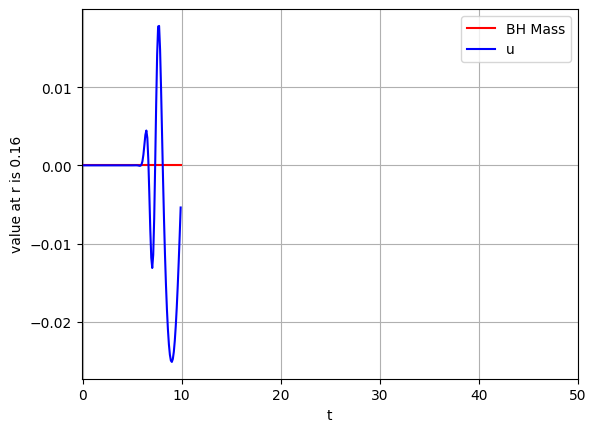

In [28]:
# Plot a single point versus time

var1 = 12

omega, ah_radius, bh_mass = get_horizon_diagnostics(solution, t, grid, background, my_matter)

#plt.set_title('AH finder')
plt.plot(t, bh_mass, 'r-', label="BH Mass")
#plt.plot(t, ah_radius, 'g--', label="AH Radius")


idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.xlim(-0.1, 50)

print(bh_mass[-1])

plt.legend(loc='best')
plt.grid()

# Oscillon evolution over time and space

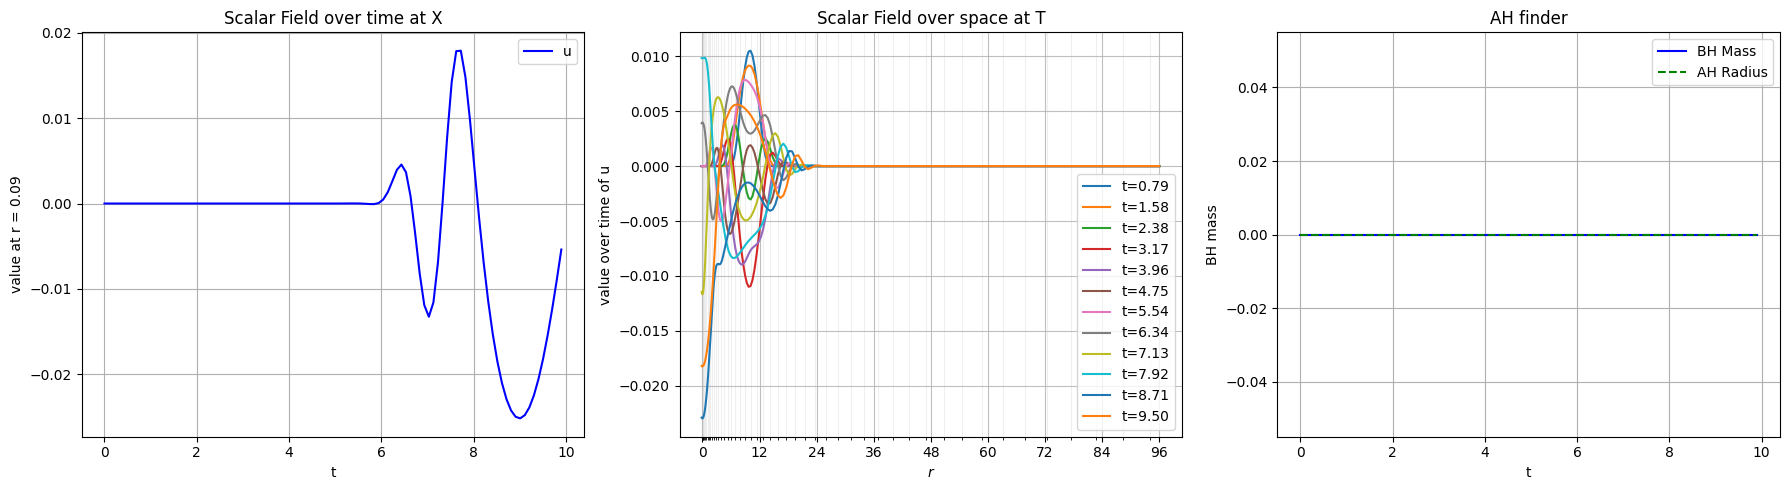

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------- (1) Evolution over time at fixed r ----------
ax = axes[0]
var1 = my_matter.idx_u
idx = NUM_GHOSTS + 1
r_i = np.round(r[idx], 2)
var1_of_t = solution[:, var1 * num_points + idx]
ax.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])
ax.set_title('Scalar Field over time at X')
ax.set_xlabel('t')
ax.set_ylabel(f'value at r = {r_i}')
ax.legend(loc='best')
ax.grid(True)

# ---------- (2) Profile evolution over r at different times ----------
ax = axes[1]
var = my_matter.idx_u
for i, t_i in enumerate(t):
    if (0 < t_i < 10) and (i % 8 == 0):
        labelt = f"t={t_i:.2f}"
        f_t = solution[i, var * num_points:(var + 1) * num_points]
        ax.plot(r, f_t, label=labelt)

ax.set_title('Scalar Field over space at T')
ax.set_xlabel('r')
ax.set_ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])
ax.legend(loc=4)
set_grid_on_ax(ax, r)
# ax.set_xlim(-0.2, 40.0)
# ax.set_ylim(-0.001, 0.001)

# ---------- (3) Black hole mass and horizon radius ----------
ax = axes[2]
omega, ah_radius, bh_mass = get_horizon_diagnostics(solution, t, grid, background, my_matter)
ax.set_title('AH finder')
ax.plot(t, bh_mass, 'b-', label="BH Mass")
ax.plot(t, ah_radius, 'g--', label="AH Radius")
ax.set_xlabel('t')
ax.set_ylabel('BH mass')
ax.legend(loc='best')
ax.grid(True)
# ax.set_ylim(-0.1, 1.3)

# ---------- Final layout ----------
plt.tight_layout()
plt.show()


# Constraint Checking

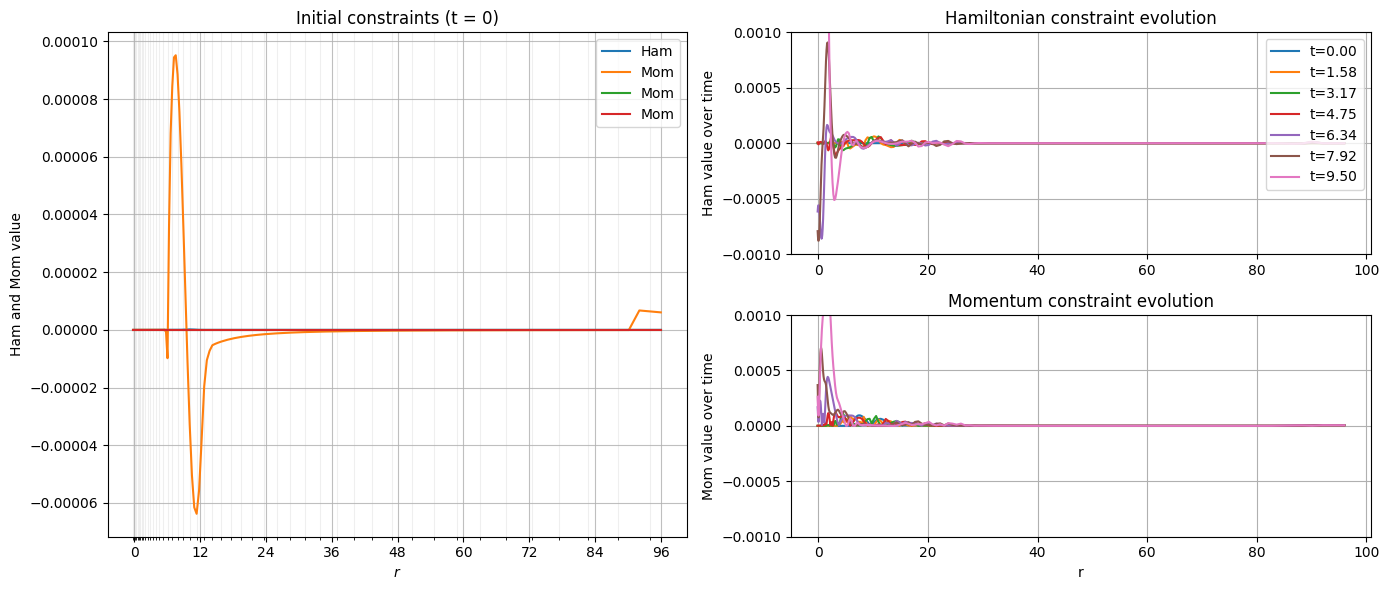

In [26]:
fig = plt.figure(figsize=(14, 6))

# ---------- (1) Initial constraints on the left ----------
ax_left = plt.subplot(1, 2, 1)
Ham0, Mom0 = get_constraints_diagnostic(initial_state, np.array([0]), grid, background, my_matter,ppp)

ax_left.plot(r, Ham0[0], label="Ham")
ax_left.plot(r, Mom0[0], label="Mom")
ax_left.set_xlabel('r')
ax_left.set_ylabel('Ham and Mom value')
ax_left.legend(loc="best")
ax_left.grid(True)
set_grid_on_ax(ax_left, r)
ax_left.set_title('Initial constraints (t = 0)')

# ---------- (2) Time evolution on the right (two stacked plots) ----------
# Create a gridspec with two rows and one column for the right-hand panel
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 1])  # top-right: Hamiltonian constraint
ax2 = fig.add_subplot(gs[1, 1])  # bottom-right: Momentum constraint

Ham, Mom = get_constraints_diagnostic(solution, t, grid, background, my_matter,ppp)
for i, t_i in enumerate(t):
    if (i < num_points_t) and (i % 16 == 0):
        labelt = f"t={t_i:.2f}"
        Ham_t = Ham[i, :]
        Mom_t = np.sqrt(Mom[i, :, i_r]**2 + Mom[i, :, i_t]**2 + Mom[i, :, i_p]**2)
        ax1.plot(r, Ham_t, label=labelt)
        ax2.plot(r, Mom_t, label=labelt)

# Formatting
ax1.set_ylabel('Ham value over time')
ax1.set_ylim(-1e-3, 1e-3)
ax1.grid(True)
ax1.legend(loc='best')

ax2.set_xlabel('r')
ax2.set_ylabel('Mom value over time')
ax2.set_ylim(-1e-3, 1e-3)
ax2.grid(True)
ax1.set_title('Hamiltonian constraint evolution')
ax2.set_title('Momentum constraint evolution')

plt.tight_layout()
plt.show()


#

# _______________________________________________________________________________________________________________________________________

#

IndexError: list index out of range

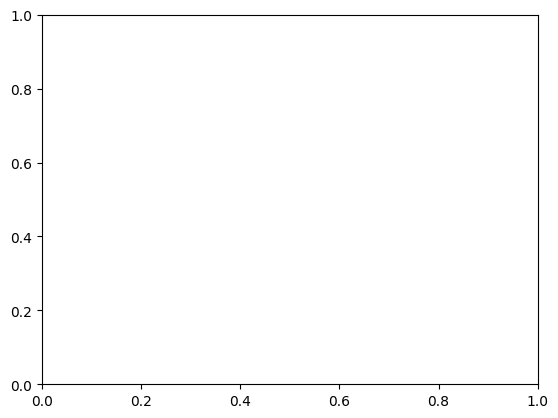

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots()

# --- choose a base color (pick one from the palette below) ---
#base_hex = "#1f77b4"   # Blue
# base_hex = "#ff7f0e" # Orange
base_hex = "#2ca02c" # Green
# base_hex = "#9467bd" # Purple
# base_hex = "#d62728" # Red
# base_hex = "#17becf" # Teal

base_rgb = mpl.colors.to_rgb(base_hex)

var = my_matter.idx_u

# select times to plot and sort by time (early first)
sel = sorted([(i, ti) for i, ti in enumerate(t) if (150 < ti < 200) and (i % 8 == 0)],
             key=lambda x: x[1])
tmins, tmaxs = sel[0][1], sel[-1][1]

# map time -> alpha (earlier = smaller alpha, later = closer to 1)
alpha_min, alpha_max = 0.25, 1.0    # tweak to taste
def alpha_of_time(ti):
    if tmaxs == tmins:
        return alpha_max
    frac = (ti - tmins) / (tmaxs - tmins)
    return alpha_min + frac * (alpha_max - alpha_min)

for i, ti in sel:
    f_t = solution[i, var*num_points:(var+1)*num_points]
    ax.plot(r, f_t, color=base_rgb, alpha=alpha_of_time(ti), label=f"t={ti:.2f}")

# Legend is fine if you don't use a colorbar (colorbars don't show alpha)
ax.legend(loc=4, ncol=2)

ax.set_xlabel('r')
ax.set_ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])
set_grid_on_ax(ax, r)
plt.show()


In [35]:
# calculate the diagnostics, just the Hamiltonian constraint for now
Ham, Mom = get_constraints_diagnostic(solution, t, grid, background, my_matter)

In [33]:
'''
# Animation of the fields (u, v) varying in time
from matplotlib import animation
%matplotlib notebook

# Select variable to plot (u or v)
var_to_plot_id, var_label = my_matter.idx_u, r'$u(t,r)$'
#var_to_anim_id, var_label = my_matter.idx_uidx_v, r'$v(t,r)$'

# Pick it out of the solution vector
var_to_anim = solution[:, var_to_plot_id * num_points:var_to_plot_id * num_points + num_points]

# Set up the figure, the axis, and the plot element we want to animate
fig = plt.figure()
ax = plt.axes(xlim=(r[NUM_GHOSTS], r[-NUM_GHOSTS]), ylim=(1.1*np.min(var_to_anim), 1.1*np.max(var_to_anim)))
line, = plt.plot([], [], lw=2)
ax.set_xlabel(r'$r$')
ax.set_ylabel(var_label)
plt.grid()

def init():
    line.set_data([], [])
    return line,

# Animation function. This is called sequentially
def animate(i):
    x = r[NUM_GHOSTS:-NUM_GHOSTS]
    y = var_to_anim[i][NUM_GHOSTS:-NUM_GHOSTS]
    line.set_data(x, y)
    return line,

# Call the animator
# anim = animation.FuncAnimation(fig, animate, init_func=init, frames=np.arange(0,num_points_t,1), interval=100, blit=True)

#Display the animation interactively.
#from IPython.display import HTML
#HTML(anim.to_jshtml())

# Option to save the animation - requires a codec e.g. FFMPEG
#anim.save('./field_animation.mp4', writer = 'ffmpeg', fps = 20)
'''

"\n# Animation of the fields (u, v) varying in time\nfrom matplotlib import animation\n%matplotlib notebook\n\n# Select variable to plot (u or v)\nvar_to_plot_id, var_label = my_matter.idx_u, r'$u(t,r)$'\n#var_to_anim_id, var_label = my_matter.idx_uidx_v, r'$v(t,r)$'\n\n# Pick it out of the solution vector\nvar_to_anim = solution[:, var_to_plot_id * num_points:var_to_plot_id * num_points + num_points]\n\n# Set up the figure, the axis, and the plot element we want to animate\nfig = plt.figure()\nax = plt.axes(xlim=(r[NUM_GHOSTS], r[-NUM_GHOSTS]), ylim=(1.1*np.min(var_to_anim), 1.1*np.max(var_to_anim)))\nline, = plt.plot([], [], lw=2)\nax.set_xlabel(r'$r$')\nax.set_ylabel(var_label)\nplt.grid()\n\ndef init():\n    line.set_data([], [])\n    return line,\n\n# Animation function. This is called sequentially\ndef animate(i):\n    x = r[NUM_GHOSTS:-NUM_GHOSTS]\n    y = var_to_anim[i][NUM_GHOSTS:-NUM_GHOSTS]\n    line.set_data(x, y)\n    return line,\n\n# Call the animator\n# anim = animation